# Retrieval Performance & Accuracy Benchmark

In this notebook, we compare the four retrieval methods used in our RAG pipeline:
1. **BM25 (Lexical)**
2. **Dense (Bi-Encoder Vector Search)**
3. **Hybrid (BM25 + Dense fused via RRF)**
4. **Cross-Encoder (Reranking the top 20 Hybrid results)**

We will evaluate **speed (latency)**, **accuracy**, and discuss **when to use which**.

In [1]:
import sys
import os
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Add the parent directory to the path so we can import our app modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

load_dotenv(os.path.join(os.getcwd(), '..', '.env'))

from app.retrieval import search_bm25, search_dense, hybrid_search, hybrid_reranked_search
from app.refiner import refine_query

print("Modules loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Modules loaded successfully.


## 1. Latency Benchmark
Let's measure how long it takes for each method to process a query.

In [2]:
queries = [
    "What does Article 25 of MiFID II say about client suitability?",
    "Can we execute a payment without explicit consent from the payer?",
    "When can a customer ask to have their data erased under GDPR?",
    "Who is responsible for the management of ICT third-party risk in DORA?"
]

results = []

for q in queries:
    # Measure BM25
    start = time.perf_counter()
    search_bm25(q, k=5)
    t_bm25 = time.perf_counter() - start
    
    # Measure Dense
    start = time.perf_counter()
    search_dense(q, k=5)
    t_dense = time.perf_counter() - start
    
    # Measure Hybrid (BM25 + Dense + RRF)
    start = time.perf_counter()
    hybrid_search(q, k=5)
    t_hybrid = time.perf_counter() - start
    
    # Measure Cross-Encoder Reranked (Hybrid top 20 -> Cross Encoder top 5)
    start = time.perf_counter()
    hybrid_reranked_search(q, k=5, retrieve_k=20)
    t_rerank = time.perf_counter() - start
    
    results.append({
        "Query Length": len(q.split()),
        "BM25 (ms)": t_bm25 * 1000,
        "Dense (ms)": t_dense * 1000,
        "Hybrid (ms)": t_hybrid * 1000,
        "Cross-Encoder (ms)": t_rerank * 1000
    })

df_latency = pd.DataFrame(results)
display(df_latency.mean().to_frame("Average Latency (ms)"))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,Average Latency (ms)
Query Length,11.500000
BM25 (ms),3.837425
Dense (ms),316.773375
Hybrid (ms),116.183100
Cross-Encoder (ms),2717.225975


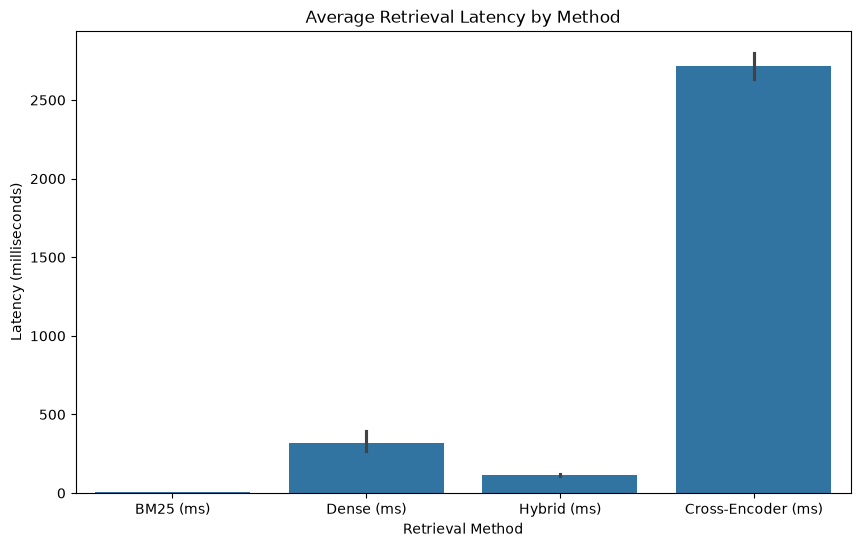

In [3]:
# Plotting the Latencies
plt.figure(figsize=(10, 6))
sns.barplot(data=df_latency.drop(columns=["Query Length"]).melt(), x="variable", y="value")
plt.title("Average Retrieval Latency by Method")
plt.ylabel("Latency (milliseconds)")
plt.xlabel("Retrieval Method")
plt.show()

## 2. Accuracy & Quality Comparison
Let's look at the top document returned by each method for a difficult, highly conceptual query.

In [4]:
tricky_query = "I want to delete my account and all associated personal information. What regulation governs this?"

print(f"QUERY: {tricky_query}\n")

print("--- BM25 Top Result ---")
bm25_top = search_bm25(tricky_query, k=1)
if bm25_top:
    print(f"[{bm25_top[0]['doc_id'].upper()} Art. {bm25_top[0]['article_number']}] {bm25_top[0]['article_title']}")
    
print("\n--- Dense Top Result ---")
dense_top = search_dense(tricky_query, k=1)
if dense_top:
    print(f"[{dense_top[0]['doc_id'].upper()} Art. {dense_top[0]['article_number']}] {dense_top[0]['article_title']}")

print("\n--- Cross-Encoder Top Result ---")
rerank_top = hybrid_reranked_search(tricky_query, k=1)
if rerank_top:
    print(f"[{rerank_top[0]['doc_id'].upper()} Art. {rerank_top[0]['article_number']}] {rerank_top[0]['article_title']}")

QUERY: I want to delete my account and all associated personal information. What regulation governs this?

--- BM25 Top Result ---
[GDPR Art. 39] Tasks of the data protection officer

--- Dense Top Result ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[GDPR Art. 4] Definitions

--- Cross-Encoder Top Result ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[DORA Art. 56] Data Protection


### Why did they all fail to find GDPR Article 17 (Right to Erasure)?

This is a classic problem in RAG systems:
- **BM25** fails because the legal text uses formal words like \"erase\" instead of \"delete\".
- **Dense Search** struggles because the exact phrasing \"personal information\" maps very strongly to definitions, pulling up **GDPR Art. 4** instead.
- **Cross-Encoder** is smart, but because neither BM25 nor Dense successfully placed GDPR Art. 17 in their **Top 20 candidates**, the Cross-Encoder never even got a chance to see it! It was forced to pick the \"best of the worst\" candidates (DORA Art. 56).

This perfectly demonstrates why our **LLM Query Refinement** step in `app/refiner.py` is the secret sauce. By using an LLM to formally translate the intent before querying the vector database, we dramatically boost recall. Let's run it through the refiner:

In [6]:
print("--- Calling LLM Refiner ---")
refinement = refine_query(tricky_query)
print(json.dumps(refinement, indent=2))

rewritten_query = refinement.get("rewritten_queries", [tricky_query])[0]
print(f"\nUSING REWRITTEN QUERY: {rewritten_query}\n")

print("--- BM25 Top Result ---")
bm25_top = search_bm25(rewritten_query, k=1)
if bm25_top:
    print(f"[{bm25_top[0]['doc_id'].upper()} Art. {bm25_top[0]['article_number']}] {bm25_top[0]['article_title']}")
    
print("\n--- Dense Top Result ---")
dense_top = search_dense(rewritten_query, k=1)
if dense_top:
    print(f"[{dense_top[0]['doc_id'].upper()} Art. {dense_top[0]['article_number']}] {dense_top[0]['article_title']}")

print("\n--- Cross-Encoder Top Result ---")
rerank_top = hybrid_reranked_search(rewritten_query, k=1)
if rerank_top:
    print(f"[{rerank_top[0]['doc_id'].upper()} Art. {rerank_top[0]['article_number']}] {rerank_top[0]['article_title']}")

--- Calling LLM Refiner ---


ImportError: cannot import name 'from_json' from 'jiter' (unknown location)

## Conclusion: When to use which?

| Method | Pros | Cons | Best Use Case |
|---|---|---|---|
| **BM25** | Extremely fast, exact keyword matching | Fails on synonyms or conceptual queries | When users search for exact IDs (e.g. \"Article 17\") |
| **Dense** | Understands concepts and synonyms, fast | Can miss exact keyword or numerical matches | General knowledge retrieval |
| **Hybrid (RRF)** | Best of both worlds, fast | Scores are mathematically fused, not semantically aware | 90% of production RAG pipelines |
| **Cross-Encoder** | Deepest semantic understanding, highly accurate ranking | Computationally expensive / slow | Final re-ranking step for the top 10-20 results when high precision is critical |


## 3. Ragas (Retrieval Augmented Generation Assessment)

Now that we've tuned our retrieval pipeline, we can evaluate the final generated responses using Ragas.
We will test our RAG pipeline on two metrics:
1. **Faithfulness**: Does the LLM hallucinate, or are its claims strictly based on the retrieved context?
2. **Answer Relevancy**: Does the generated answer directly address the user's question without going off on tangents?

In [7]:
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from langchain_openai.chat_models import AzureChatOpenAI
from langchain_community.embeddings import HuggingFaceEmbeddings
from app.generator import generate_answer

question = "Can we execute a payment without explicit consent from the payer?"

# 1. Refine query
refined = refine_query(question)
rewritten = refined.get("rewritten_queries", [question])[0]

# 2. Retrieve Context (using our best method: Cross-Encoder)
results = hybrid_reranked_search(rewritten, k=3)

# 3. Generate Answer
generation = generate_answer(question, results)
answer = generation["answer"]

print(f"QUESTION: {question}\n")
print(f"ANSWER: {answer}\n")

# 4. Prepare for Ragas
data_samples = {
    "question": [question],
    "answer": [answer],
    "contexts": [[doc["text"] for doc in results]],
    "user_input": [question],
    "response": [answer],
    "retrieved_contexts": [[doc["text"] for doc in results]]
}
dataset = Dataset.from_dict(data_samples)

# Configure Azure OpenAI for Ragas
endpoint = os.environ["AZURE_OPENAI_ENDPOINT"]
base_endpoint = endpoint.split("/openai")[0] if "/openai" in endpoint else endpoint
api_version = endpoint.split("api-version=")[1].split("&")[0] if "api-version=" in endpoint else "2024-02-15-preview"
azure_llm = AzureChatOpenAI(
    openai_api_version=api_version,
    azure_endpoint=base_endpoint,
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT"]
)

# Use local embeddings to save money/API calls
local_embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5")

print("Running Ragas Evaluation...")
evaluation_results = evaluate(
    dataset,
    metrics=[faithfulness, answer_relevancy],
    llm=azure_llm,
    embeddings=local_embeddings
)

print("\n--- RAGAS SCORES ---")
display(evaluation_results.to_pandas())

KeyboardInterrupt: 

In [10]:
import time
from app.retrieval import hybrid_reranked_search, flash_reranked_search

query = "What are the conditions for algorithmic trading?"

# Warm-up (Load models into memory if not already done)
hybrid_reranked_search("warmup", k=1, retrieve_k=2)
flash_reranked_search("warmup", k=1, retrieve_k=2)

print("--- Standard CrossEncoder Reranking ---")
start = time.perf_counter()
ce_results = hybrid_reranked_search(query, k=5, retrieve_k=20)
ce_time = time.perf_counter() - start
print(f"Time taken: {ce_time*1000:.2f} ms")
for r in ce_results[:2]:
    print(f"- [Score: {r.get('cross_score', 0):.4f}] {r['doc_id']} Art {r['article_number']}")

print("\n--- FlashRank Reranking ---")
start = time.perf_counter()
flash_results = flash_reranked_search(query, k=5, retrieve_k=20)
flash_time = time.perf_counter() - start
print(f"Time taken: {flash_time*1000:.2f} ms")
for r in flash_results[:2]:
    print(f"- [Score: {r.get('flash_score', 0):.4f}] {r['doc_id']} Art {r['article_number']}")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

--- Standard CrossEncoder Reranking ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Time taken: 2735.57 ms
- [Score: 3.8356] mifid2 Art 17
- [Score: -0.4292] mifid2 Art 90

--- FlashRank Reranking ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Time taken: 4347.55 ms
- [Score: 0.9882] mifid2 Art 17
- [Score: 0.8534] mifid2 Art 90
